In [1]:
from pprint import pprint

import arviz as az
import arviz_plots
import matplotlib.pyplot as plt
import numpyro
import pandas as pd

from vaxflux import (
    LogisticCurve,
    PooledGaussianCovariate,
    VaxfluxModel,
)
from vaxflux.data import sample_dataset
from vaxflux.dates import SeasonRange, daily_date_ranges

numpyro.set_host_device_count(8)
az.style.use("arviz-docgrid")

In [2]:
seasons = [
    SeasonRange(season="2022/23", start_date="2022-10-03", end_date="2023-02-05"),
    SeasonRange(season="2023/24", start_date="2023-10-02", end_date="2024-02-04"),
    SeasonRange(season="2024/25", start_date="2024-10-07", end_date="2025-02-02"),
]
dates = daily_date_ranges(seasons, range_days=6)

In [3]:
covariates = [
    PooledGaussianCovariate(
        parameter="m",
        covariate=None,
        mu=0.0,
        sigma=0.75,
    ),
    PooledGaussianCovariate(
        parameter="r",
        covariate=None,
        mu=-2.5,
        sigma=1.5,
    ),
    PooledGaussianCovariate(
        parameter="s",
        covariate=None,
        mu=35.0,
        sigma=20.0,
    ),
]

In [4]:
curve = LogisticCurve()
curve

In [5]:
params = []

params_grid = {
    "2022/23": {
        "m": -0.5,
        "r": -3.2,
        "s": 40.0,
    },
    "2023/24": {
        "m": -0.6,
        "r": -3.1,
        "s": 42.5,
    },
    "2024/25": {
        "m": -0.4,
        "r": -3.3,
        "s": 41.0,
    },
}

for curve_param in curve.parameters:
    for season_range in seasons:
        season_params = params_grid[season_range.season]
        params.append(
            (
                curve_param,
                season_range.season,
                season_params[curve_param],
            ),
        )

pprint(params)

[('m', '2022/23', -0.5),
 ('m', '2023/24', -0.6),
 ('m', '2024/25', -0.4),
 ('r', '2022/23', -3.2),
 ('r', '2023/24', -3.1),
 ('r', '2024/25', -3.3),
 ('s', '2022/23', 40.0),
 ('s', '2023/24', 42.5),
 ('s', '2024/25', 41.0)]


In [6]:
observations = sample_dataset(
    curve,
    seasons,
    dates,
    [],
    params,
    epsilon=0.0005,
)

observations.head()

,season,season_start_date,season_end_date,start_date,end_date,report_date,type,value
0,2022/23,2022-10-03,2023-02-05,2022-10-03,2022-10-09,2022-10-09,incidence,0.016363
1,2022/23,2022-10-03,2023-02-05,2022-10-10,2022-10-16,2022-10-16,incidence,0.017805
2,2022/23,2022-10-03,2023-02-05,2022-10-17,2022-10-23,2022-10-23,incidence,0.022075
3,2022/23,2022-10-03,2023-02-05,2022-10-24,2022-10-30,2022-10-30,incidence,0.023066
4,2022/23,2022-10-03,2023-02-05,2022-10-31,2022-11-06,2022-11-06,incidence,0.025045


/var/folders/2z/h3pc0p7s3ng1tvxrgsw5kr680000gp/T/ipykernel_8399/947640.py:28: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0, 0, 0.85, 1))


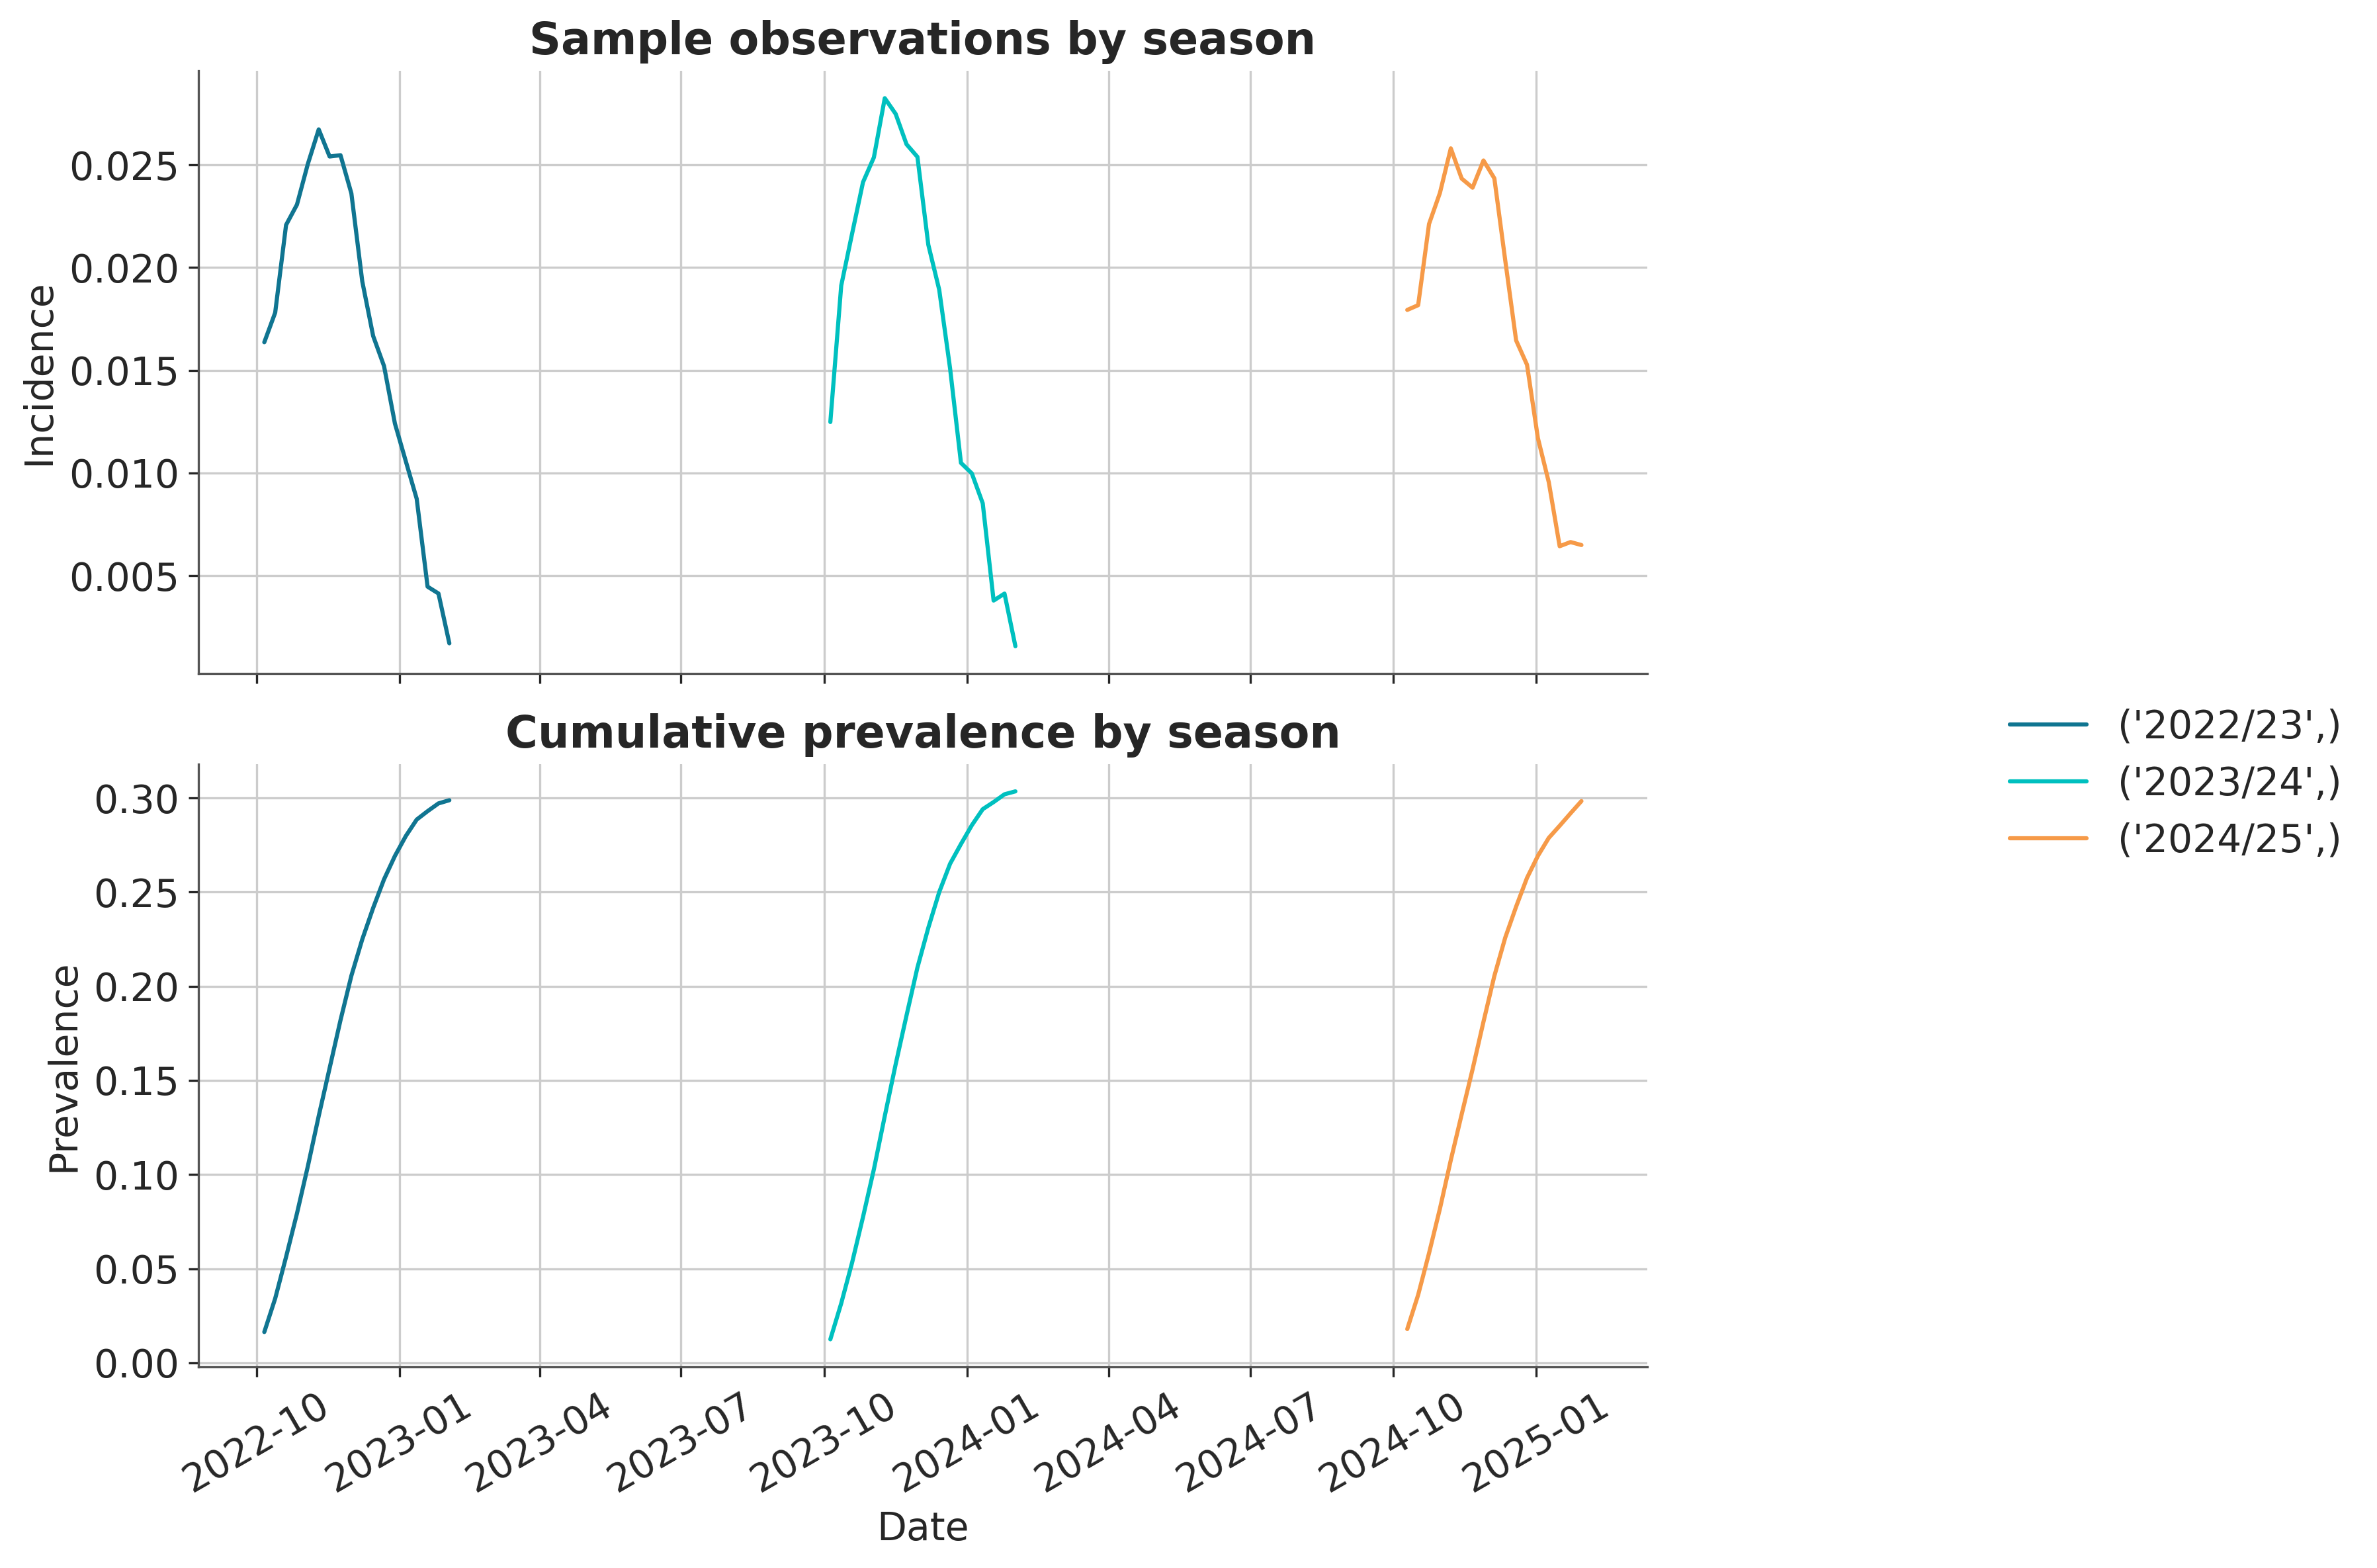

In [7]:
plot_data = observations.copy()
plot_data["start_date"] = pd.to_datetime(plot_data["start_date"])
plot_data["end_date"] = pd.to_datetime(plot_data["end_date"])
plot_data["mid_date"] = (
    plot_data["start_date"] + (plot_data["end_date"] - plot_data["start_date"]) / 2
)
plot_data = plot_data.sort_values("mid_date")
plot_data["prevalence"] = plot_data.groupby(["season"])["value"].cumsum()

fig, (ax_inc, ax_prev) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for season, group in plot_data.groupby(["season"]):
    label = f"{season}"
    ax_inc.plot(group["mid_date"], group["value"], label=label)
    ax_prev.plot(group["mid_date"], group["prevalence"], label=label)

ax_inc.set_title("Sample observations by season")
ax_inc.set_ylabel("Incidence")

ax_prev.set_title("Cumulative prevalence by season")
ax_prev.set_ylabel("Prevalence")
ax_prev.set_xlabel("Date")

handles, labels = ax_inc.get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5))
for label in ax_prev.get_xticklabels():
    label.set_rotation(30)
fig.tight_layout(rect=(0, 0, 0.85, 1))
plt.show()

In [8]:
model = (
    VaxfluxModel(curve=curve)
    .add_seasons(seasons)
    .add_dates(dates)
    .add_covariates(covariates)
    .add_observations(observations)
    .add_observation_process(
        kind="normal",
        noise=0.005,
        partially_pool_by_season=False,
        prevalence_penalty=10.0,
    )
)
model

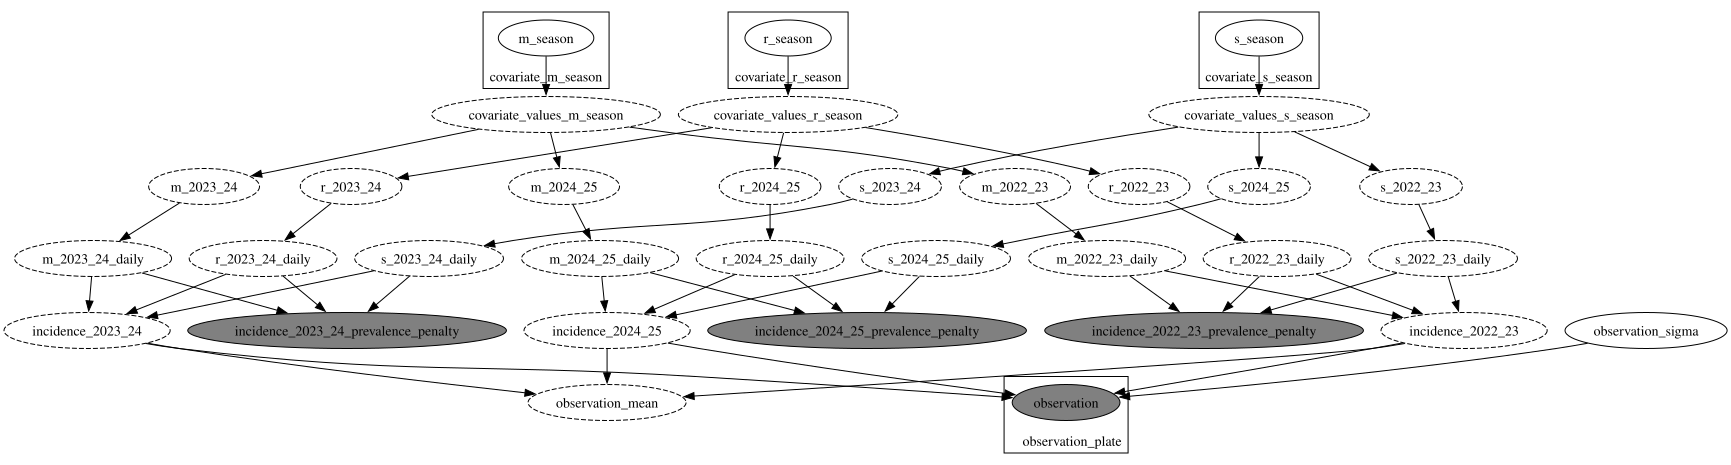

In [9]:
model.render_model(render_params=True)

In [10]:
prior_samples = 500
vaxflux_prior_idata = model.sample(samples=None, prior_samples=prior_samples)
vaxflux_prior_idata

Inference data with groups:
	> prior

In [11]:
vaxflux_prior_idata.prior_observations

,chain,draw,season,season_start_date,season_end_date,start_date,end_date,report_date,type,value
0,0,0,2022/23,2022-10-03,2023-02-05,2022-11-07,2022-11-13,2022-11-13,incidence,0.062233
1,0,0,2022/23,2022-10-03,2023-02-05,2022-12-19,2022-12-25,2022-12-25,incidence,0.004291
2,0,0,2022/23,2022-10-03,2023-02-05,2022-12-12,2022-12-18,2022-12-18,incidence,0.008037
3,0,0,2022/23,2022-10-03,2023-02-05,2023-01-23,2023-01-29,2023-01-29,incidence,0.000163
4,0,0,2022/23,2022-10-03,2023-02-05,2022-11-14,2022-11-20,2022-11-20,incidence,0.054544
...,...,...,...,...,...,...,...,...,...,...
26495,0,499,2024/25,2024-10-07,2025-02-02,2024-11-18,2024-11-24,2024-11-24,incidence,0.054303
26496,0,499,2024/25,2024-10-07,2025-02-02,2024-12-09,2024-12-15,2024-12-15,incidence,0.000021
26497,0,499,2024/25,2024-10-07,2025-02-02,2024-11-25,2024-12-01,2024-12-01,incidence,0.004311
26498,0,499,2024/25,2024-10-07,2025-02-02,2024-10-14,2024-10-20,2024-10-20,incidence,0.000080


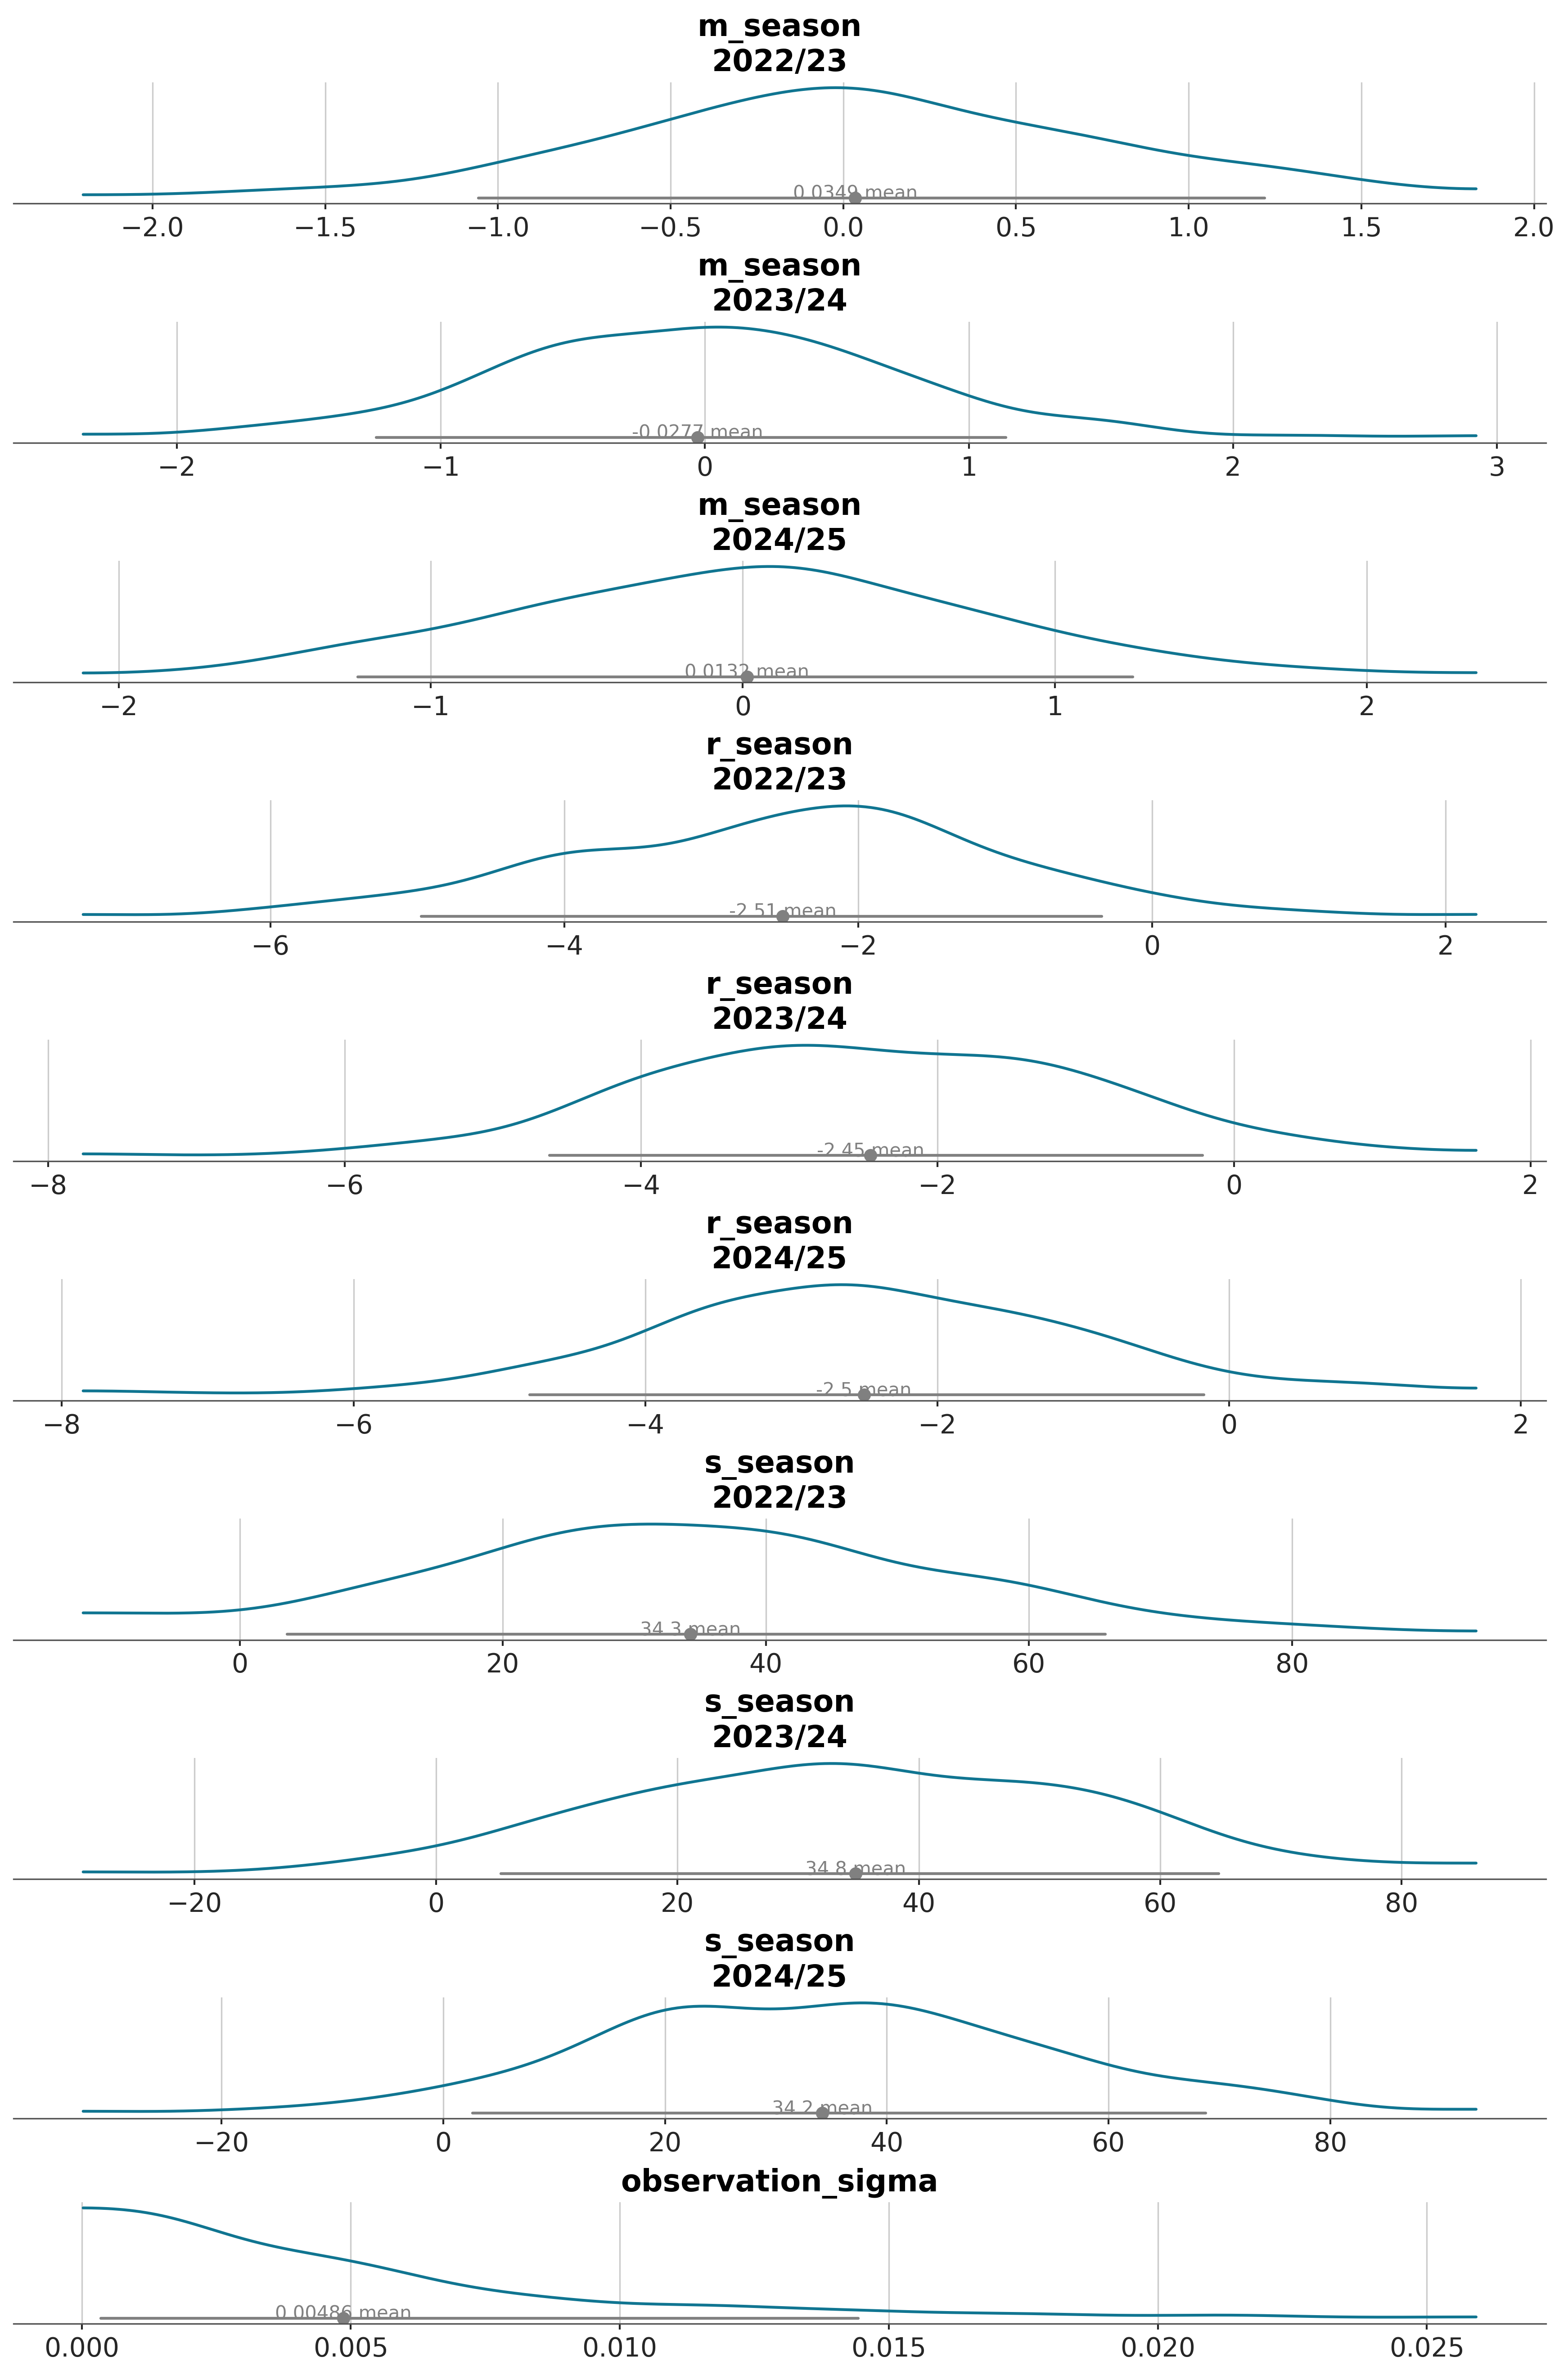

In [12]:
arviz_plots.plot_dist(
    vaxflux_prior_idata,
    group="prior",
    var_names=[
        "m_season",
        "r_season",
        "s_season",
        "observation_sigma",
    ],
    pc_kwargs={"col_wrap": 1},
)
plt.show()

/Users/twillard/Desktop/GitHub/ACCIDDA/vaxflux/src/vaxflux/_vaxflux_inference_data.py:478: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


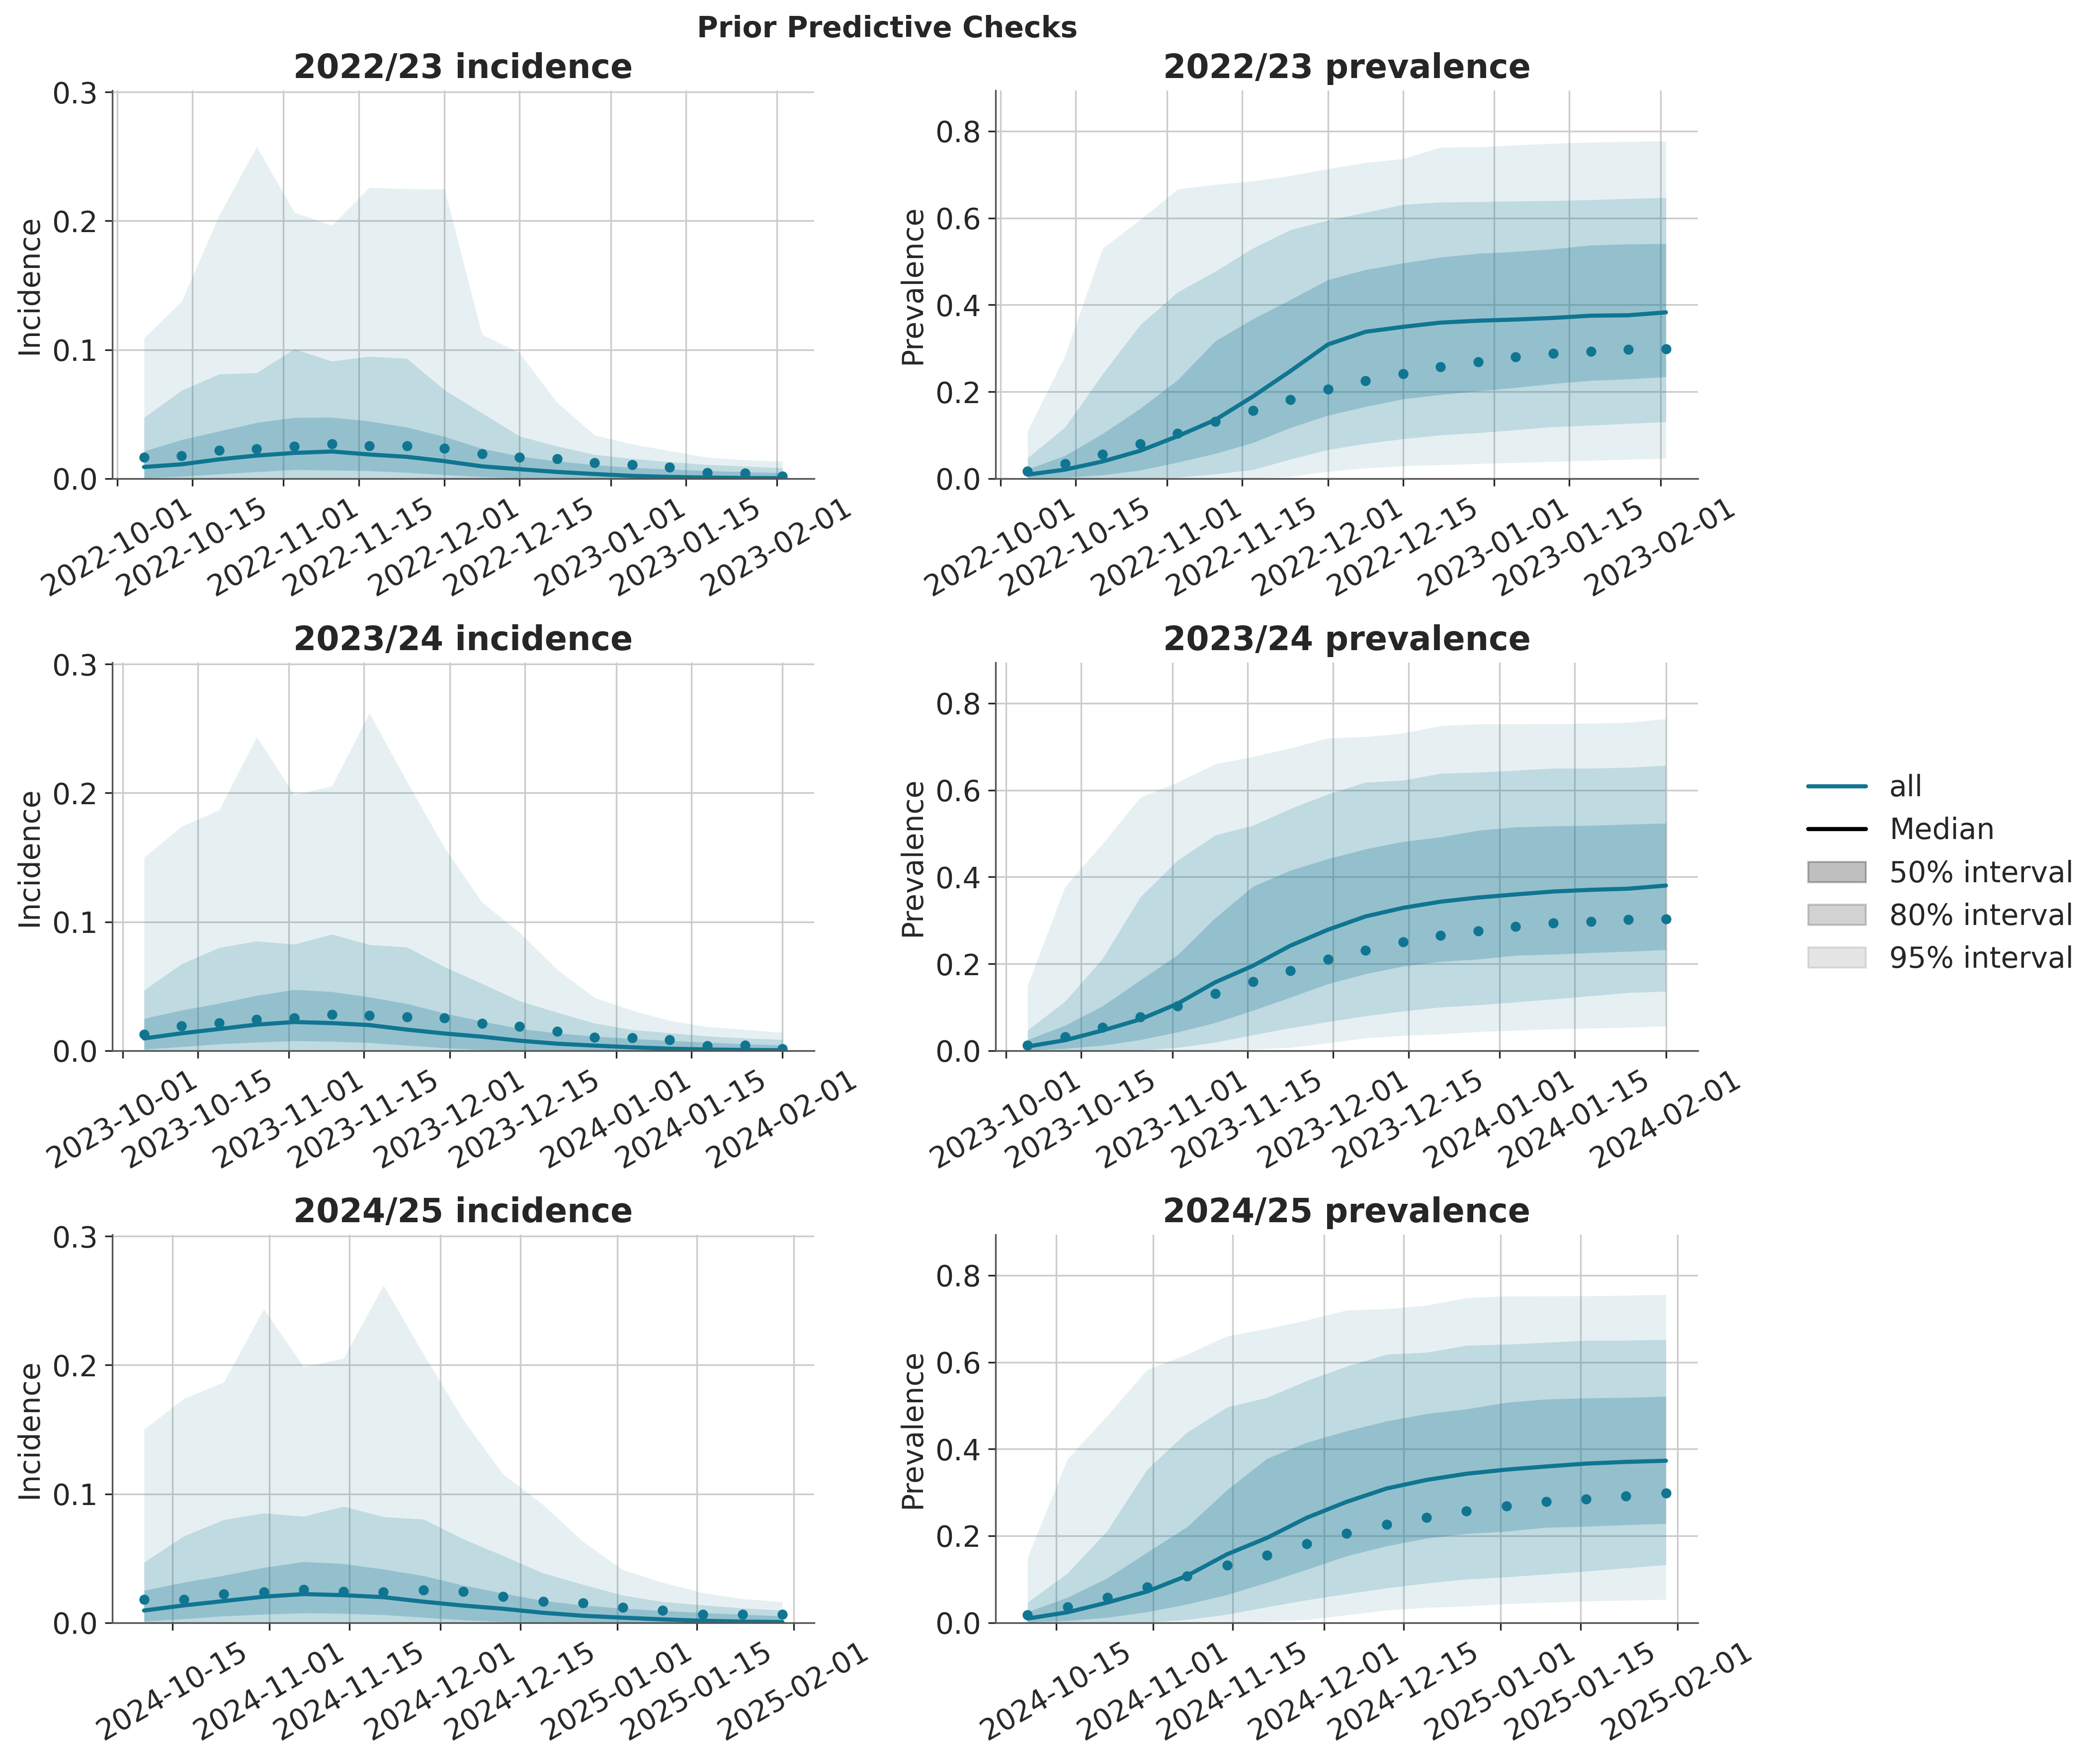

In [13]:
vaxflux_prior_idata.plot_prior_predictive()
plt.show()

In [14]:
warmup = 500
samples = 500
chains = 4
vaxflux_idata = model.sample(
    warmup=warmup, samples=samples, prior_samples=None, chains=chains
)
vaxflux_idata

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> observed_data

In [15]:
vaxflux_idata.posterior_observations

,chain,draw,season,season_start_date,season_end_date,start_date,end_date,report_date,type,value
0,0,0,2022/23,2022-10-03,2023-02-05,2022-11-07,2022-11-13,2022-11-13,incidence,0.026803
1,0,0,2022/23,2022-10-03,2023-02-05,2022-12-19,2022-12-25,2022-12-25,incidence,0.014030
2,0,0,2022/23,2022-10-03,2023-02-05,2022-12-12,2022-12-18,2022-12-18,incidence,0.017019
3,0,0,2022/23,2022-10-03,2023-02-05,2023-01-23,2023-01-29,2023-01-29,incidence,0.004087
4,0,0,2022/23,2022-10-03,2023-02-05,2022-11-14,2022-11-20,2022-11-20,incidence,0.026546
...,...,...,...,...,...,...,...,...,...,...
105995,3,499,2024/25,2024-10-07,2025-02-02,2024-11-18,2024-11-24,2024-11-24,incidence,0.026189
105996,3,499,2024/25,2024-10-07,2025-02-02,2024-12-09,2024-12-15,2024-12-15,incidence,0.020492
105997,3,499,2024/25,2024-10-07,2025-02-02,2024-11-25,2024-12-01,2024-12-01,incidence,0.025059
105998,3,499,2024/25,2024-10-07,2025-02-02,2024-10-14,2024-10-20,2024-10-20,incidence,0.018164


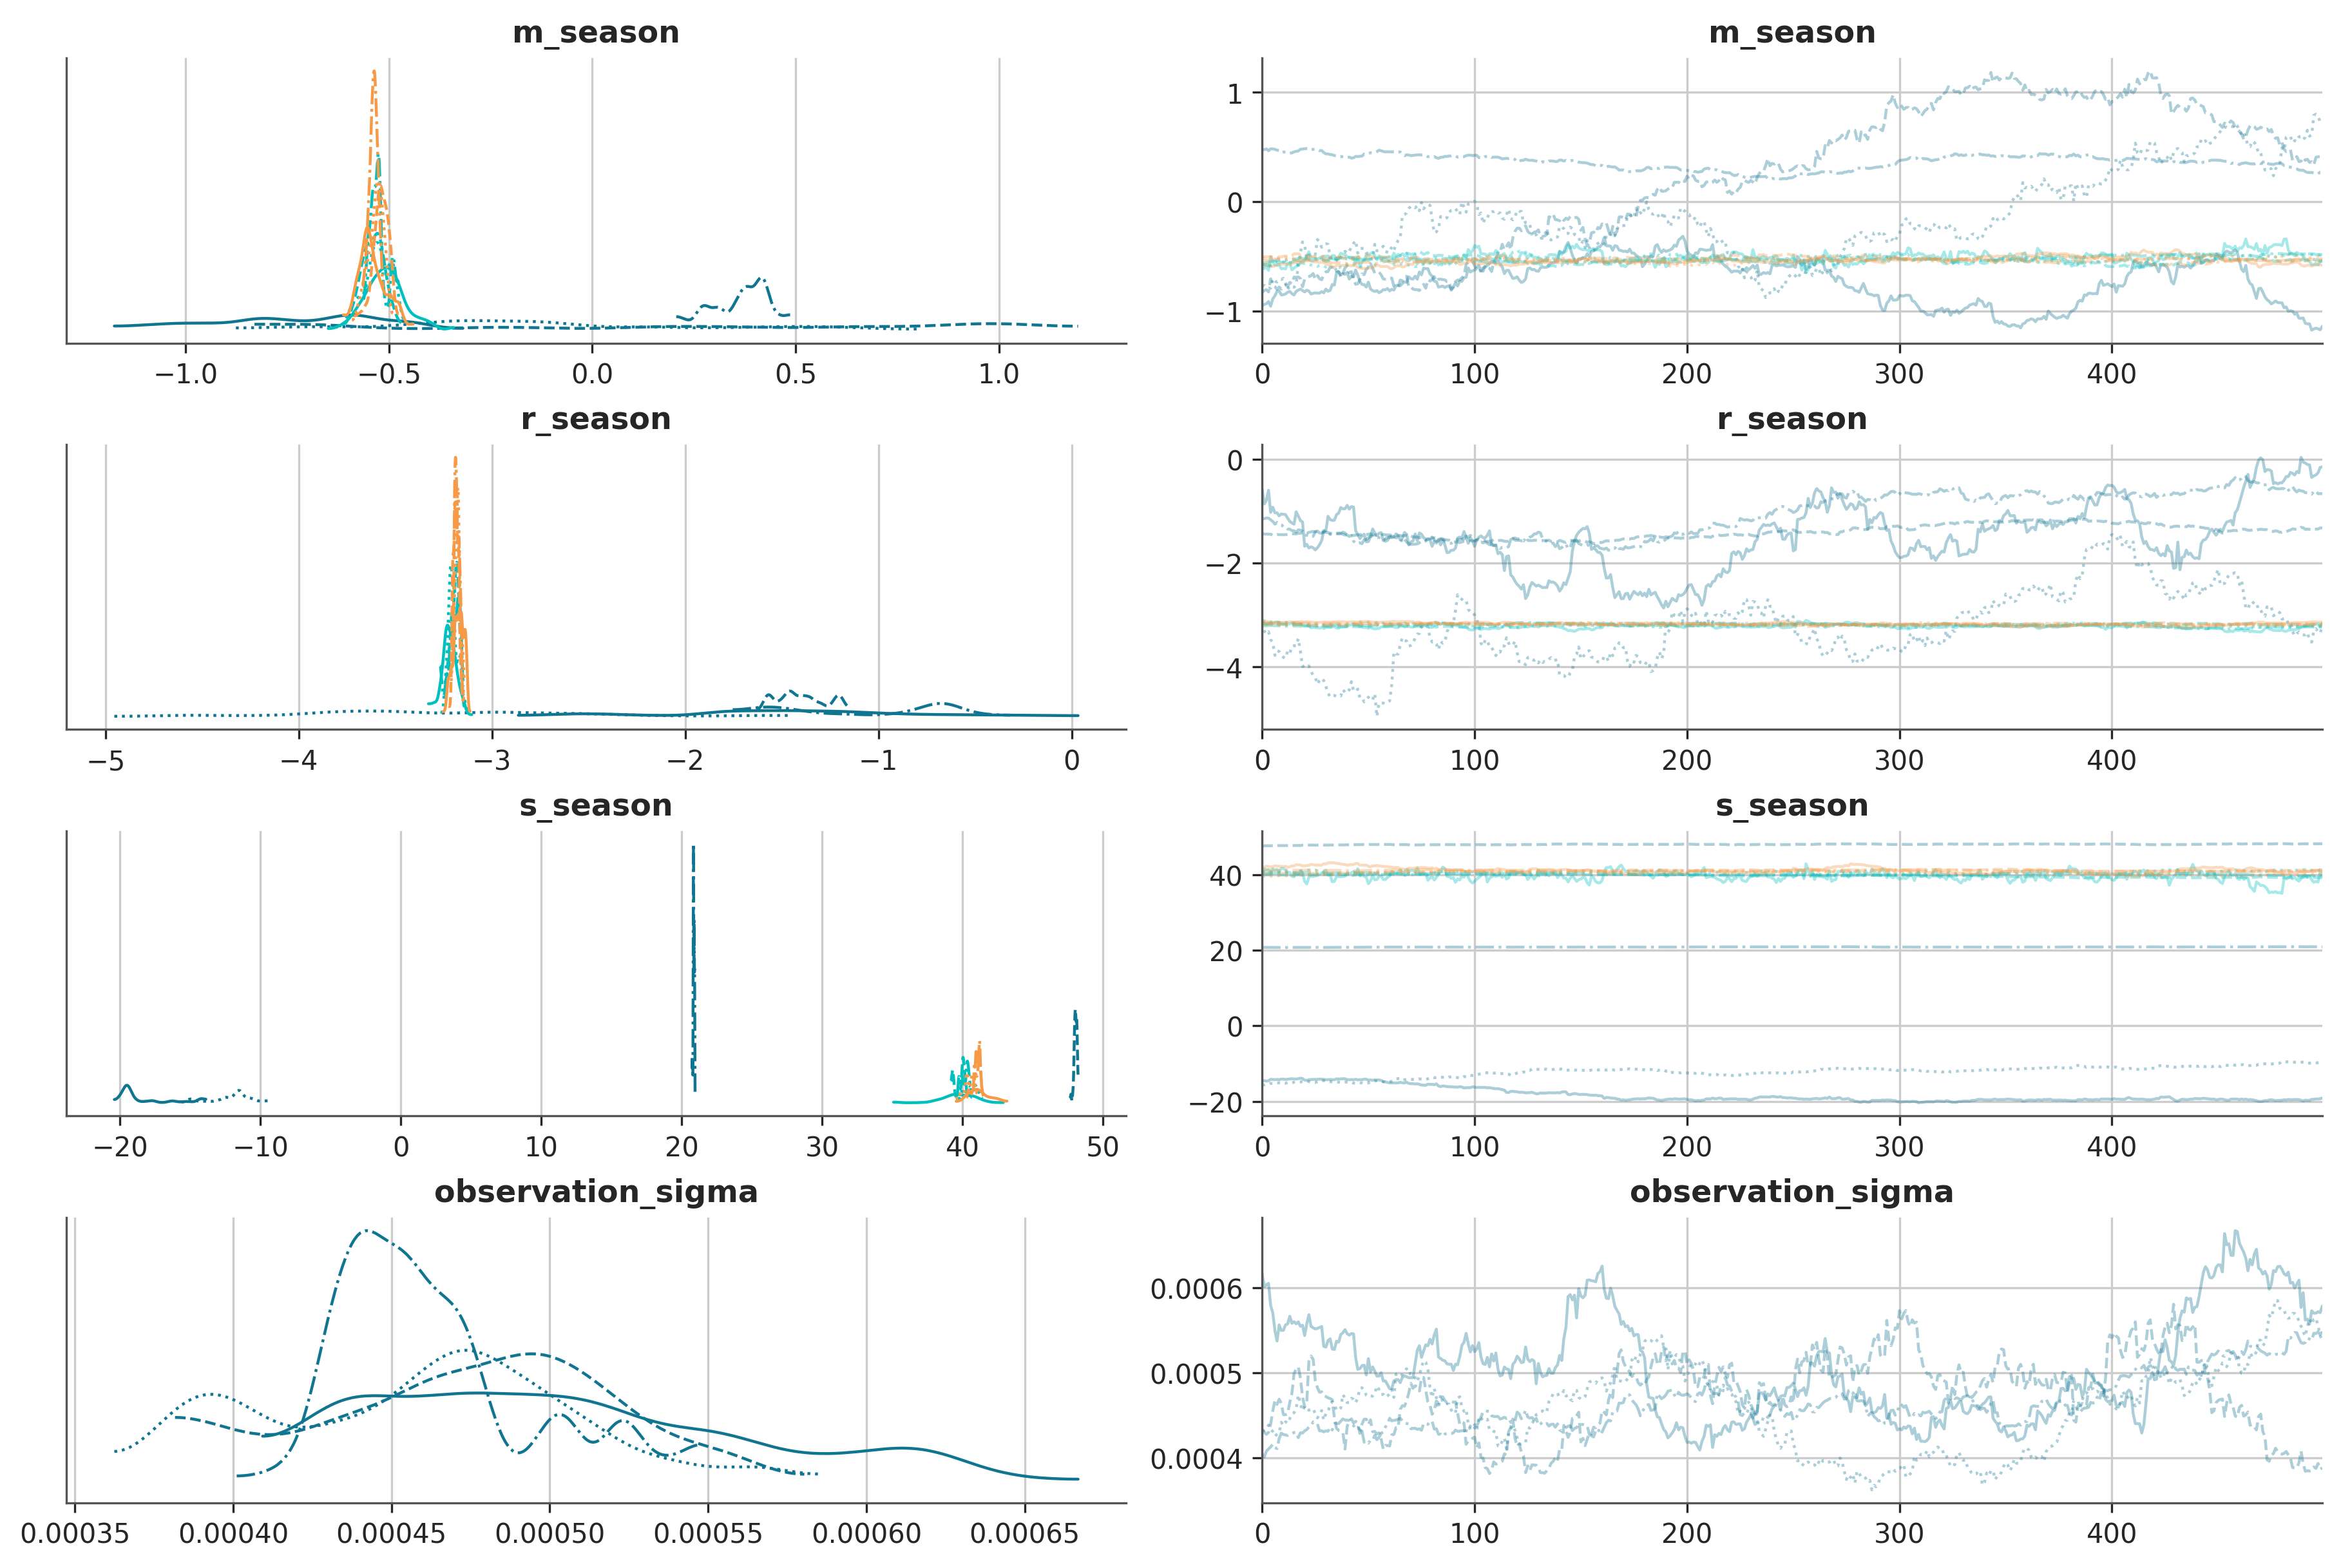

In [16]:
az.plot_trace(
    vaxflux_idata,
    var_names=[
        "m_season",
        "r_season",
        "s_season",
        "observation_sigma",
    ],
)
plt.show()

/Users/twillard/Desktop/GitHub/ACCIDDA/vaxflux/src/vaxflux/_vaxflux_inference_data.py:478: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


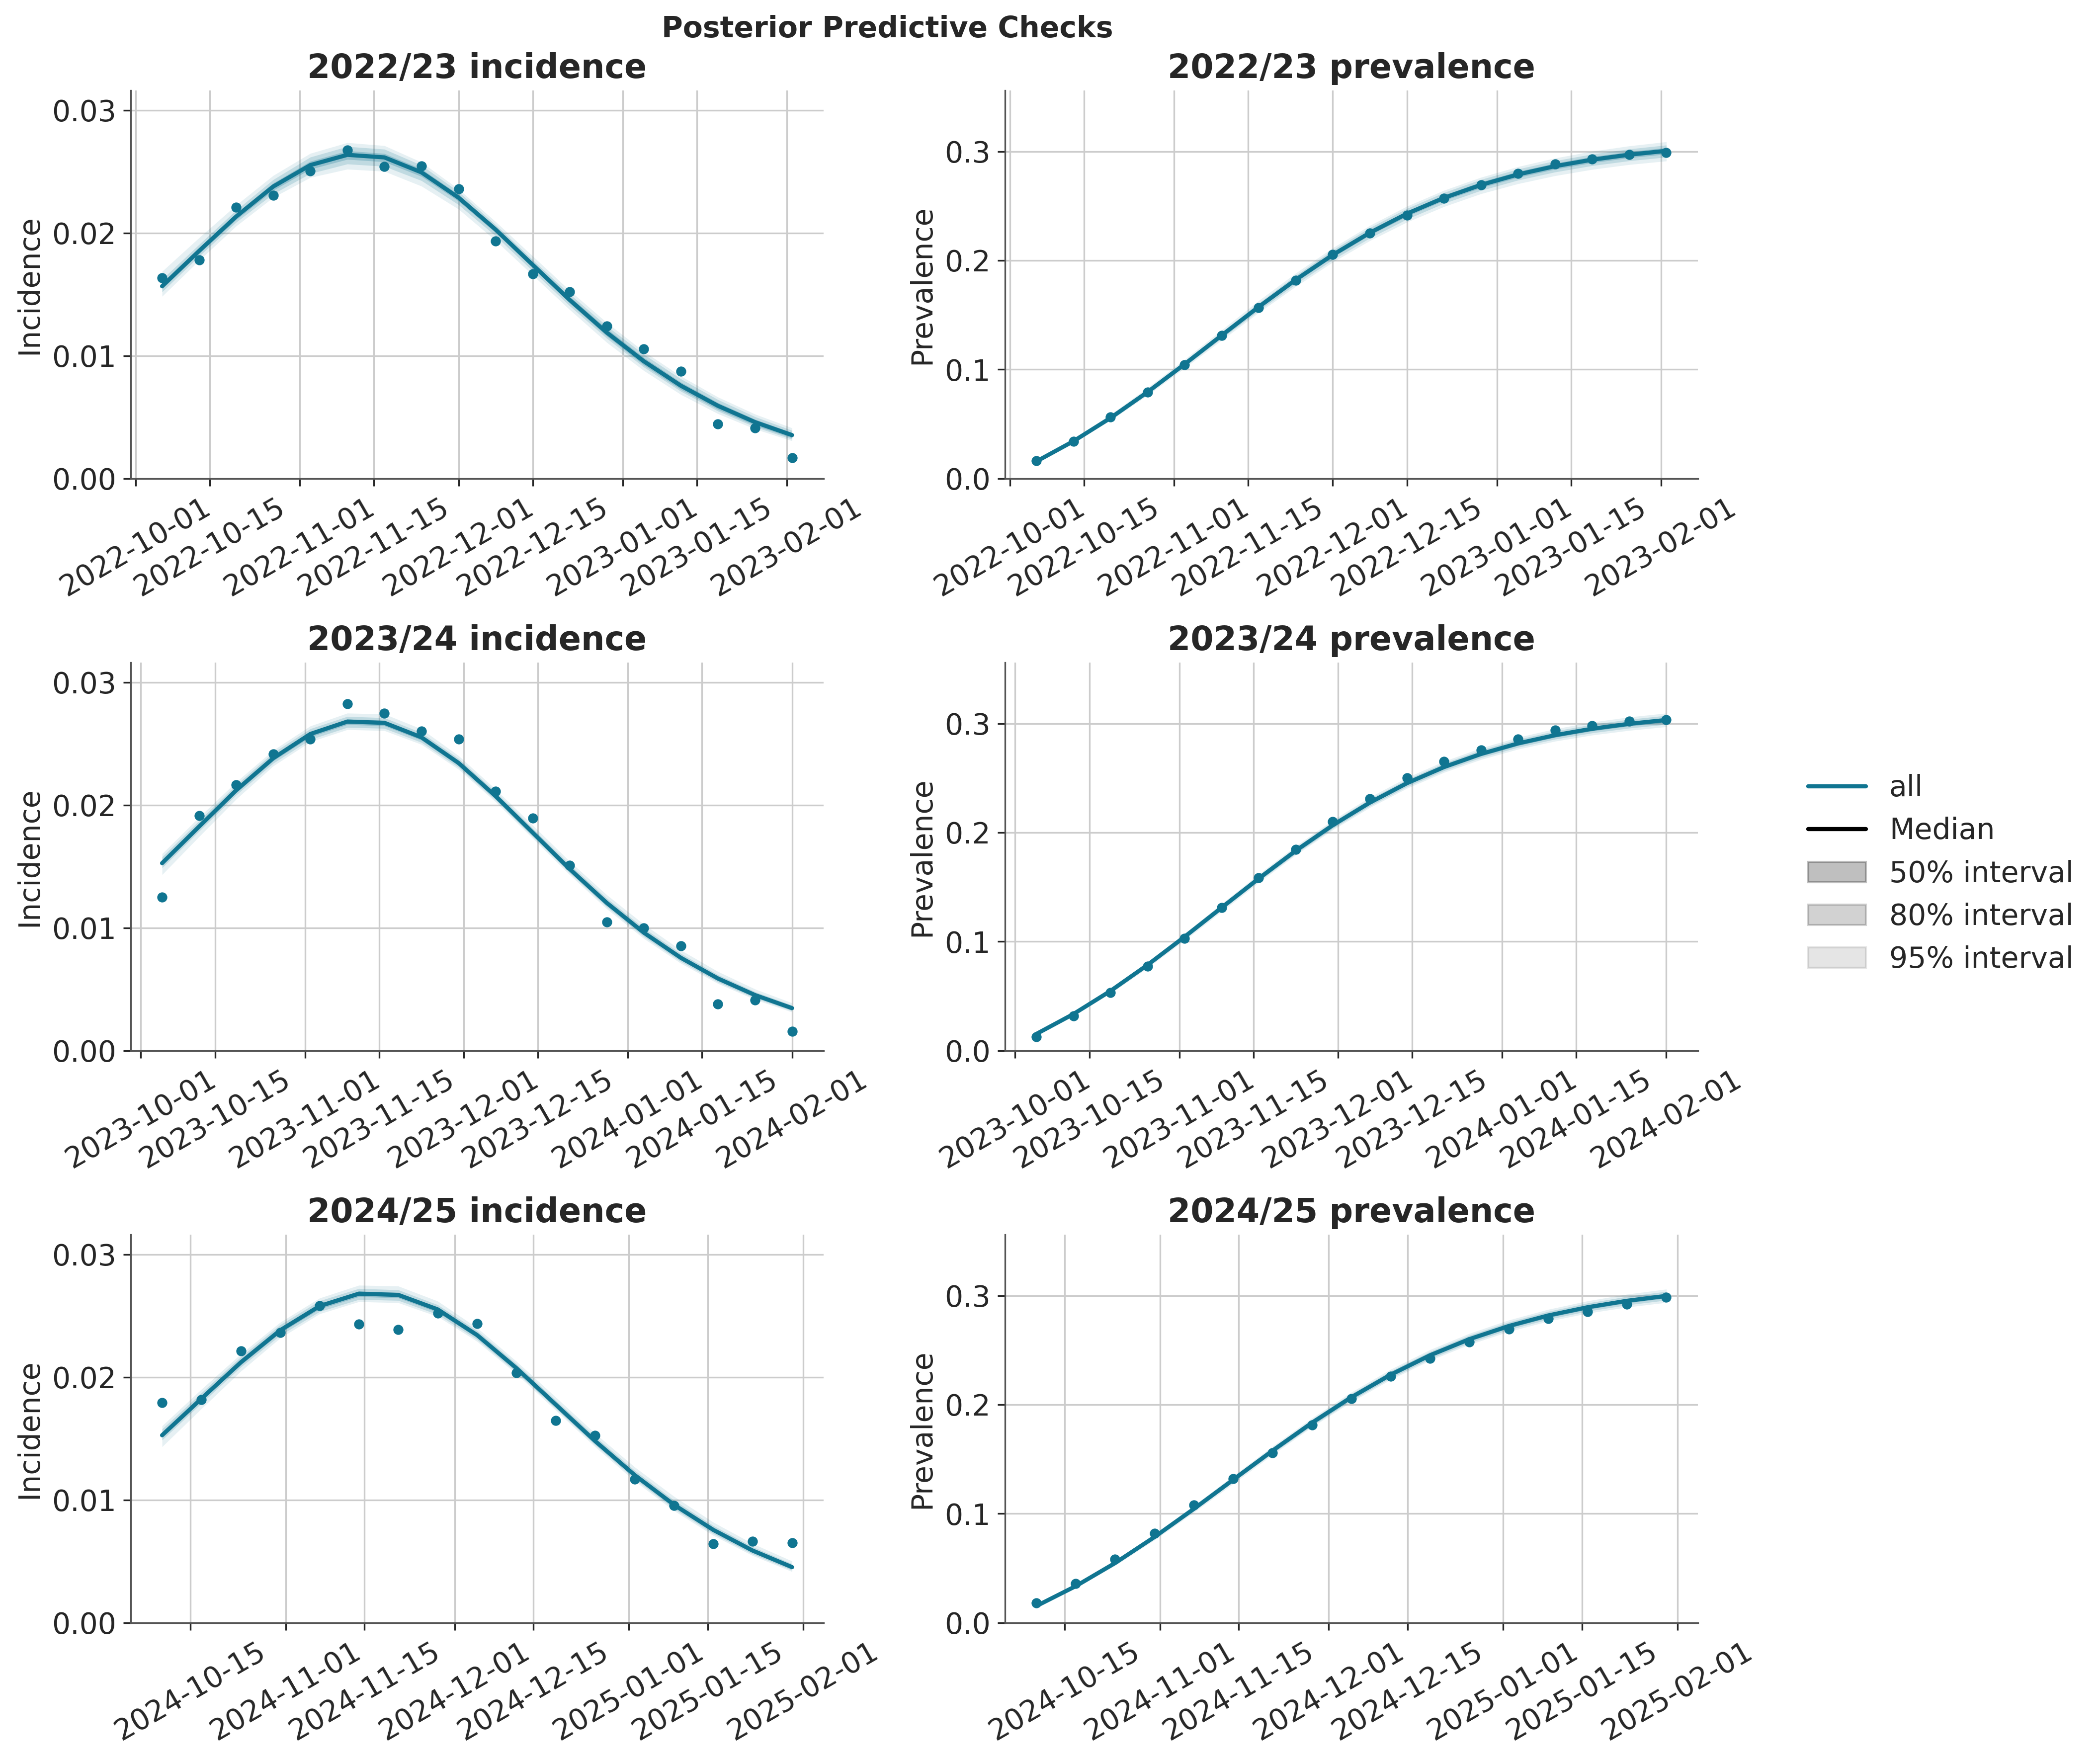

In [17]:
vaxflux_idata.plot_posterior_predictive()
plt.show()